In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [5]:
from google.colab import files

uploaded = files.upload()



Saving credit_risk_dataset.csv to credit_risk_dataset (2).csv


In [7]:
df = pd.read_csv('credit_risk_dataset.csv')
X = df.drop("default", axis=1)
y = df["default"]


In [10]:
df.head()

,age,income,loan_amount,employment_years,credit_history_years,existing_debt,debt_ratio,loan_ratio,default
0,59,36032,106015,16,15,186985,5.189271,2.942164,0
1,49,22198,212888,31,28,88774,3.999009,9.589982,0
2,35,171151,350732,21,12,152961,0.893714,2.049243,0
3,63,187292,152603,3,16,98071,0.523623,0.814782,0
4,28,192946,355484,4,2,179971,0.932748,1.842392,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [11]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
#create Model
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC(
            kernel='rbf',
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            eval_metric='logloss'
        )
}


Logistic Regression

Accuracy:
0.9833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       227
           1       0.91      0.77      0.83        13

    accuracy                           0.98       240
   macro avg       0.95      0.88      0.91       240
weighted avg       0.98      0.98      0.98       240



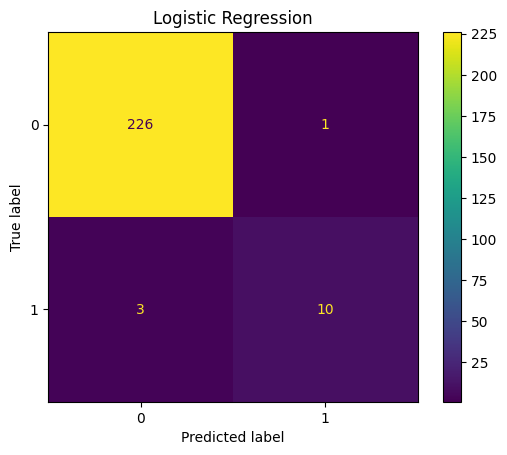


Random Forest

Accuracy:
0.9916666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       227
           1       1.00      0.85      0.92        13

    accuracy                           0.99       240
   macro avg       1.00      0.92      0.96       240
weighted avg       0.99      0.99      0.99       240



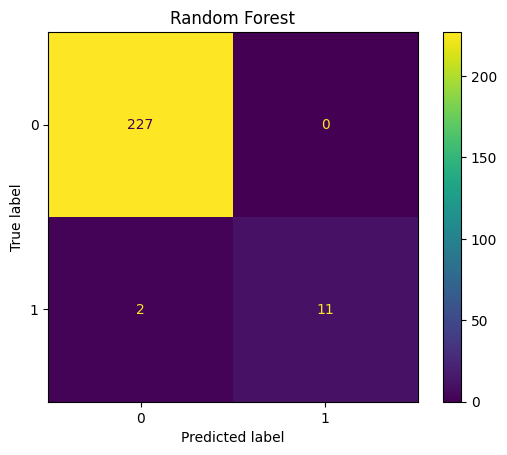


SVM

Accuracy:
0.9833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       227
           1       0.91      0.77      0.83        13

    accuracy                           0.98       240
   macro avg       0.95      0.88      0.91       240
weighted avg       0.98      0.98      0.98       240



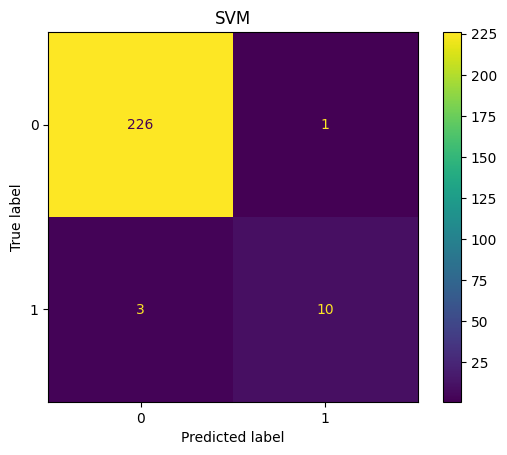


XGBoost

Accuracy:
0.9833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       227
           1       0.85      0.85      0.85        13

    accuracy                           0.98       240
   macro avg       0.92      0.92      0.92       240
weighted avg       0.98      0.98      0.98       240



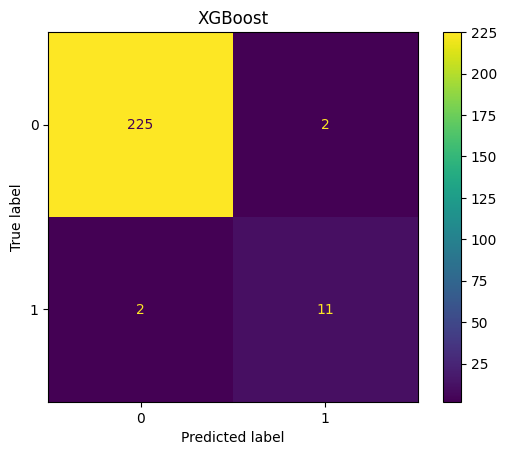

In [14]:
#train & evaluate
accuracies = {}

for name, model in models.items():

    print("\n========================")
    print(name)
    print("========================")

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, predictions)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)

    accuracies[name] = acc

    print("\nAccuracy:")
    print(acc)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(name)
    plt.show()

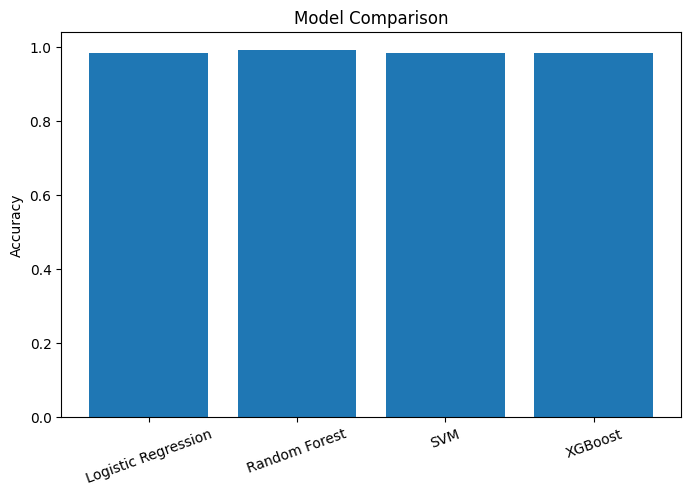

In [15]:
#accuracy comparison
names = list(accuracies.keys())
scores = list(accuracies.values())

plt.figure(figsize=(8, 5))
plt.bar(names, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

In [17]:
#best model
best_model_name = max(
    accuracies,
    key=accuracies.get
)

print("\nBest Model:")
print(best_model_name)

best_model = models[best_model_name]



Best Model:
Random Forest



Feature Importance:
                Feature  Importance
7            loan_ratio    0.209795
2           loan_amount    0.205066
6            debt_ratio    0.197948
5         existing_debt    0.159505
1                income    0.089464
3      employment_years    0.052251
4  credit_history_years    0.049592
0                   age    0.036380


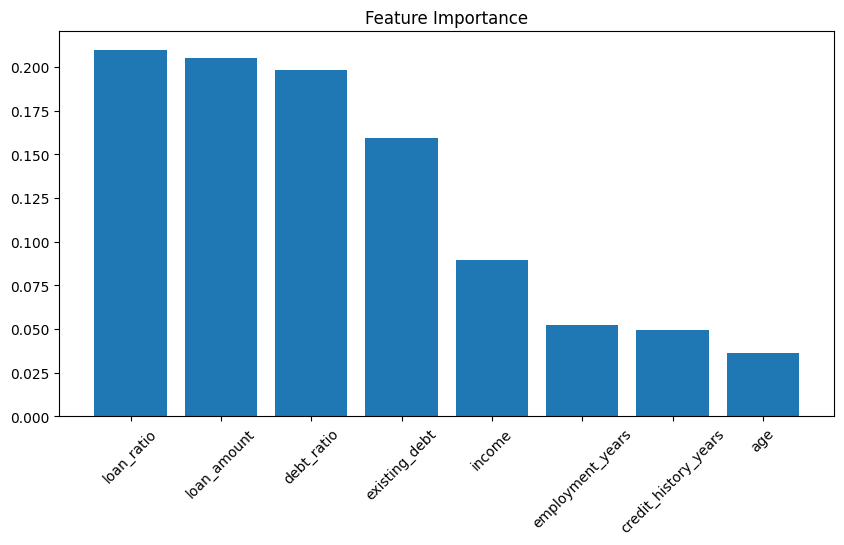

In [19]:
#feature importance
if best_model_name in [
    "Random Forest",
    "XGBoost"
]:

    importance = best_model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })

    feature_importance = (
        feature_importance
         .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\nFeature Importance:")
    print(feature_importance)

    plt.figure(figsize=(10, 5))
    plt.bar(
        feature_importance["Feature"],
        feature_importance["Importance"]
    )
    plt.xticks(rotation=45)
    plt.title("Feature Importance")
    plt.show()


In [25]:
#predict new customer
new_customer = pd.DataFrame({
    "age": [30],
    "income": [80000],
    "loan_amount": [100000],
    "employment_years": [5],
    "credit_history_years": [4],
    "existing_debt": [20000],
    "debt_ratio": [20000 / 80000],
    "loan_ratio": [100000 / 80000]
})
if best_model_name in [
    "Logistic Regression",
    "SVM"
]:
    customer = scaler.transform(new_customer)
    prediction = best_model.predict(customer)
    probability = (
        best_model.predict_proba(customer)
        [:, 1]
    )
else:
    prediction = best_model.predict(
        new_customer
    )
    probability = (
        best_model.predict_proba(new_customer)
        [:, 1]
    )
    risk_score = probability[0] * 100

print("\nPrediction:")
print(
    "Risky Customer"
    if prediction[0] == 1
    else "Safe Customer"
)

print(
    "Risk Score:",
    round(risk_score, 2),
    "/100"
)



Prediction:
Safe Customer
Risk Score: 0.5 /100
